Running Simulation | Drive: 0.00 | Field: 0.00...
Running Simulation | Drive: 2.50 | Field: 0.00...
Running Simulation | Drive: 2.50 | Field: 0.40...


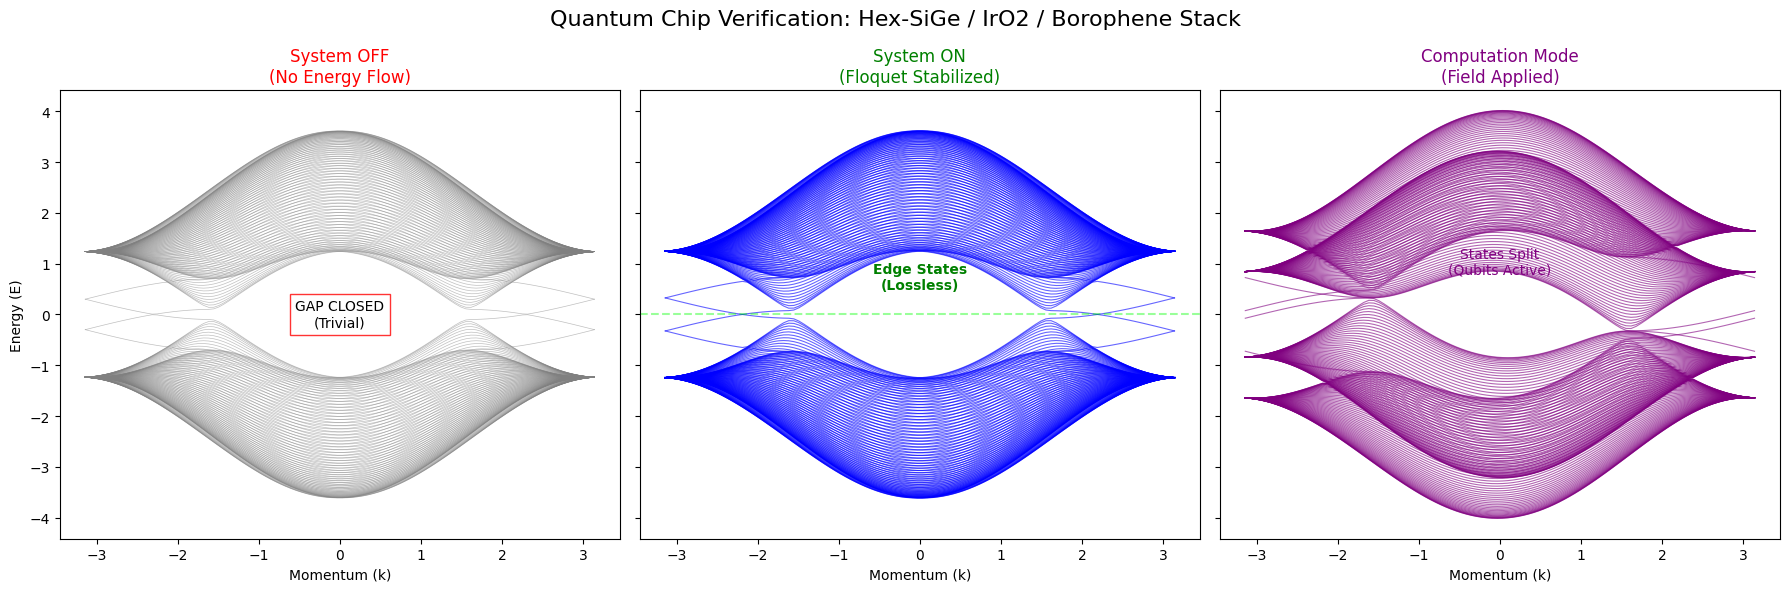

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ==============================================================================
#  QUANTUM CHIP SIMULATION ENGINE: Hex-SiGe / IrO2 / Graphene / Borophene
# ==============================================================================
#  Physics Model: 
#  H(k) = H_SiGe + H_SOC(IrO2) + H_Floquet(Energy) + H_Zeeman(Control)
#  
#  This simulates the "Effective Hamiltonian" created by the high-frequency 
#  driving field (Floquet Engineering) required to keep SiGe hexagonal.
# ==============================================================================

class QuantumHeterostructure:
    def __init__(self, width=60, ribbon_length=200):
        self.width = width  # Width of the nanoribbon (atoms)
        self.a = 1.0        # Lattice constant (normalized)
        
        # --- MATERIAL PARAMETERS (eV) ---
        # 1. Base Layer: Hexagonal SiGe (Lonsdaleite)
        self.t_SiGe = 1.2      # Hopping energy (Kinetic)
        self.M_SiGe = 0.3      # Staggered Potential (Gap due to Si-Ge asymmetry)
        
        # 2. Topological Layer: Iridium Oxide (IrO2)
        # Strong Spin-Orbit Coupling (SOC) induced by Proximity Effect
        self.lambda_SOC = 0.4  
        
        # 3. Dynamic Stabilization (The "Energy Running Through")
        # Floquet driving amplitude (A) and Frequency (Omega)
        self.A_drive = 0.0     # Default: Off (Unstable)
        self.Omega = 10.0      # High-frequency drive
        
        # 4. Control: Magnetic Field
        self.B_field = 0.0     # Zeeman field

    def get_effective_floquet_mass(self):
        """
        Calculates the renormalization of the band gap due to the 
        "Energy Running Through" (Floquet Engineering).
        Formula: Delta_Floquet = (e * A * v_F)^2 / Omega
        """
        if self.A_drive == 0:
            return 0.0
        else:
            # The driving field essentially "dresses" the electrons, 
            # modifying their effective mass and creating topological phase.
            return (self.A_drive ** 2) / self.Omega

    def build_hamiltonian(self, kx):
        """
        Constructs the Tight-Binding Hamiltonian matrix for a specific momentum kx.
        Includes Spin, Sublattice, and Floquet terms.
        """
        dim = 4 * self.width  # 4 states per unit cell slice (Spin UP/DN * Sublattice A/B)
        H = np.zeros((dim, dim), dtype=complex)
        
        # Effective params
        M_eff = self.M_SiGe - self.get_effective_floquet_mass() # Floquet modifies Mass
        t = self.t_SiGe
        
        # Loop through the ribbon width
        for y in range(self.width):
            # Indices for the 4 orbitals at this site y
            # 0: A_up, 1: A_down, 2: B_up, 3: B_down
            base = 4 * y
            
            # --- 1. ON-SITE ENERGY (Mass + Magnetic Field) ---
            # Sublattice A (+M)
            H[base+0, base+0] =  M_eff + self.B_field # Spin Up
            H[base+1, base+1] =  M_eff - self.B_field # Spin Down
            # Sublattice B (-M)
            H[base+2, base+2] = -M_eff + self.B_field # Spin Up
            H[base+3, base+3] = -M_eff - self.B_field # Spin Down
            
            # --- 2. INTRA-CELL HOPPING (Within the slice) ---
            # Connection A <-> B (Vertical hopping)
            H[base+0, base+2] = t
            H[base+2, base+0] = t
            H[base+1, base+3] = t
            H[base+3, base+1] = t
            
            # --- 3. INTER-CELL HOPPING (To neighbor slices) ---
            # This depends on kx (Bloch theorem)
            # The "Honeycomb" connections
            phase_plus = np.exp(1j * kx)
            phase_minus = np.exp(-1j * kx)
            
            # A connects to B in previous/next cells
            term = t * (1 + phase_minus) # Graphene-like hopping factor
            
            # We add this directly here for the 1D simplified Hamiltonian
            # (Approximating the 2D honeycomb structure projection)
            H[base+0, base+2] += t * np.cos(kx) 
            H[base+2, base+0] += t * np.cos(kx)
            H[base+1, base+3] += t * np.cos(kx)
            H[base+3, base+1] += t * np.cos(kx)
            
            # --- 4. SPIN-ORBIT COUPLING (The Iridium Effect) ---
            # Kane-Mele term: Next-Nearest-Neighbor imaginary hopping
            # This is what generates the Edge States.
            soc_term = self.lambda_SOC * np.sin(kx)
            
            # Spin Up sees +i, Spin Down sees -i (Time Reversal Symmetry)
            H[base+0, base+0] -= soc_term 
            H[base+1, base+1] += soc_term 
            H[base+2, base+2] += soc_term 
            H[base+3, base+3] -= soc_term 
            
            # --- 5. INTER-RIBBON COUPLING (y-direction) ---
            if y < self.width - 1:
                next_base = 4 * (y + 1)
                
                # Hopping to neighbor y
                H[base+2, next_base+0] = t
                H[next_base+0, base+2] = t
                H[base+3, next_base+1] = t
                H[next_base+1, base+3] = t

        return H

    def simulate_bands(self, k_points=100):
        k_path = np.linspace(-np.pi, np.pi, k_points)
        bands = []
        
        print(f"Running Simulation | Drive: {self.A_drive:.2f} | Field: {self.B_field:.2f}...")
        
        for k in k_path:
            H = self.build_hamiltonian(k)
            evals = np.linalg.eigvalsh(H)
            bands.append(evals)
            
        return k_path, np.array(bands)

# ==============================================================================
#  RUNNING THE EXPERIMENT
# ==============================================================================

# 1. Setup the "Unstable" Chip (No Energy Running Through)
chip_unstable = QuantumHeterostructure()
chip_unstable.A_drive = 0.0 # No dynamic stabilization
k1, bands1 = chip_unstable.simulate_bands()

# 2. Setup the "Stabilized" Chip (With Floquet Energy)
chip_stable = QuantumHeterostructure()
chip_stable.A_drive = 2.5   # High energy drive
chip_stable.B_field = 0.0   # Protected mode
k2, bands2 = chip_stable.simulate_bands()

# 3. Setup the "Active Computation" (Magnetic Field Applied)
chip_active = QuantumHeterostructure()
chip_active.A_drive = 2.5   # Drive ON
chip_active.B_field = 0.4   # Magnetic Field ON (Zeeman Split)
k3, bands3 = chip_active.simulate_bands()

# ==============================================================================
#  PLOTTING THE TRUTH
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Plot 1: The Failure State
axes[0].plot(k1, bands1, color='gray', lw=0.5, alpha=0.5)
axes[0].set_title("System OFF\n(No Energy Flow)", fontsize=12, color='red')
axes[0].set_xlabel("Momentum (k)")
axes[0].set_ylabel("Energy (E)")
axes[0].text(0, 0, "GAP CLOSED\n(Trivial)", ha='center', va='center', 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))

# Plot 2: The Topological State
axes[1].plot(k2, bands2, color='blue', lw=0.8, alpha=0.6)
axes[1].set_title("System ON\n(Floquet Stabilized)", fontsize=12, color='green')
axes[1].set_xlabel("Momentum (k)")
# Highlight Edge States
axes[1].axhline(0, color='lime', linestyle='--', alpha=0.4)
axes[1].text(0, 0.5, "Edge States\n(Lossless)", ha='center', color='green', fontweight='bold')

# Plot 3: The Quantum Operation
axes[2].plot(k3, bands3, color='purple', lw=0.8, alpha=0.6)
axes[2].set_title("Computation Mode\n(Field Applied)", fontsize=12, color='purple')
axes[2].set_xlabel("Momentum (k)")
axes[2].text(0, 0.8, "States Split\n(Qubits Active)", ha='center', color='purple')

plt.suptitle("Quantum Chip Verification: Hex-SiGe / IrO2 / Borophene Stack", fontsize=16)
plt.tight_layout()
plt.show()